In [1]:
"""
1. Injection of global noise via phase shifts and
by frequency offsets.

2. Injection of global and local noise via single
addressing beams causing stark shifts.

"""

import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(1)

(400,)


Text(0, 0.5, '$p_{diff}$')

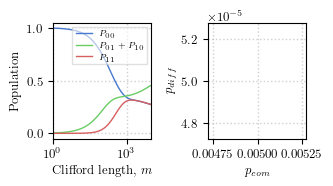

In [ ]:
m = fh.GTModel()
fig_width = gs.get_fig_width()*246/510
fig_height = gs.get_fig_width()*140/510
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_width, fig_height))

sim_line = np.logspace(0, 4, 100)
theta_com = 0.1
theta_diff = 0.01
theta_cd = np.pi/2
spam = 0.0
p_com = 1 - np.cos(theta_com)
p_diff = 1 - np.cos(theta_diff)
P = m.model(sim_line, theta_com, theta_diff, theta_cd, spam)
print(P.shape)
bin_P = len(P)//4
P00 = P[:bin_P]
P01 = P[bin_P:2*bin_P]
P10 = P[2*bin_P:3*bin_P]
P11 = P[3*bin_P:]
P0110 = [p01+p10 for p01, p10 in zip(P01, P10)]
ax1.plot(sim_line, P00, label="$P_{00}$", linestyle="-")
ax1.plot(sim_line, P0110, label="$P_{01}+P_{10}$", linestyle="-")
ax1.plot(sim_line, P11, label="$P_{11}$", linestyle="-")
ax1.set_xlabel("Clifford length, $m$")
ax1.set_ylabel("Population")
ax1.set_xlim(1, 10**4)
ax1.set_xscale("log")
ax1.legend(loc="upper right")
ax2.plot(p_com, p_diff)
ax2.set_xlabel("$p_{com}$")
ax2.set_ylabel("$p_{diff}$")